In [1]:
! pip install -e .
!pip install geodatasets

Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=3d0e51586c53a64f30e11107edb09be023d1fe1b59e1eabcca7c6785c02d980c
  Stored in directory: /tmp/pip-ephem-wheel-cache-u14giou8/wheels/0d/d8/f6/0e90ec4164bf3c02bf3bed8ede68ddfb64e3b2ef0023ebb734
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0


In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
fires = read_in_fires_and_precip()


Subsetting fires by removing Great Plains ecoregion.


In [4]:
# how many days a fire last figure

# how many times does it rain as a %? pre, 1 time, 2 times, 3 times, 4, times, final increment, immediatly after,

<Axes: >

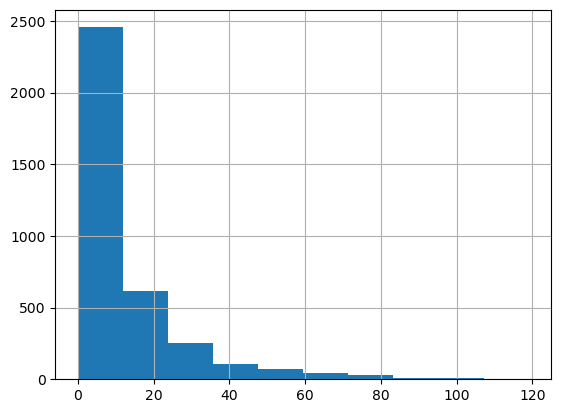

In [5]:
fires.groupby("UfireID").duration.max().hist()

In [6]:
thresh = 1


fires.loc[:, 'precip_over_thresh'] = fires.precipitation >= thresh



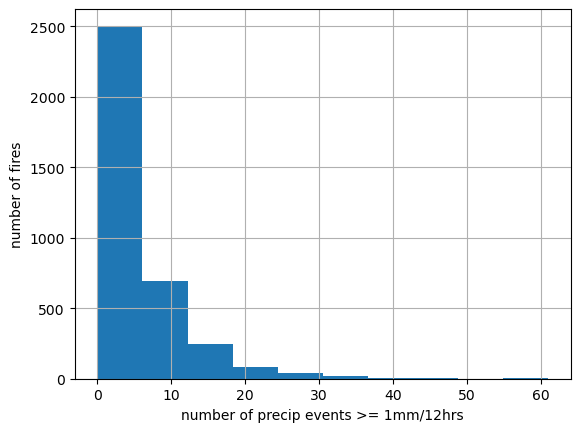

In [7]:
fires.groupby("UfireID").precip_over_thresh.sum().hist()
plt.xlabel("number of precip events >= 1mm/12hrs") # 91.186 mm over 12 hours is severe rain
plt.ylabel("number of fires")


tmp = fires[fires.fr_active_status == "during_fire"].groupby("UfireID").precip_over_thresh.sum().reset_index()

fires = fires.merge(tmp, on = "UfireID")

In [8]:
fires[fires.precip_over_thresh_y > 30].l1_ecoregion.unique()

array(['EASTERN TEMPERATE FORESTS', 'NORTHWESTERN FORESTED MOUNTAINS',
       'NORTH AMERICAN DESERTS'], dtype=object)

In [9]:
fires[(fires.precip_over_thresh_y > 30) & (fires.duration == 22.5)].UfireID #58842_2016 

foo = fires[fires.UfireID == "58842_2016"]

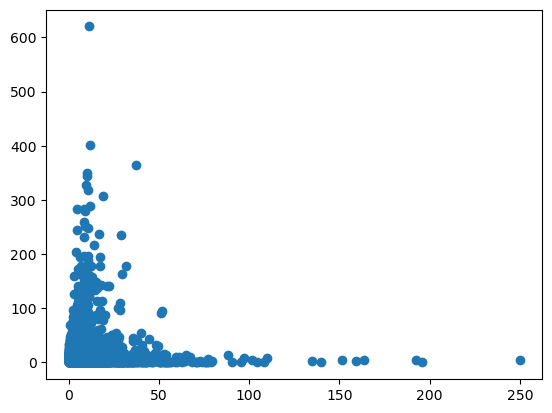

In [10]:
plt.scatter(fires.groupby("UfireID").area_growth_at_t_km2.sum() /fires.groupby("UfireID").duration.max(), fires.groupby("UfireID").precipitation.sum()/ fires.groupby("UfireID").duration.max())

Text(0.5, 0, 'cummulative area')

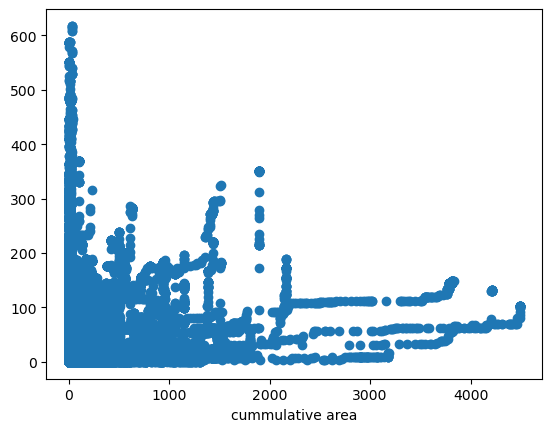

In [11]:
plt.scatter(fires.groupby("UfireID").area_growth_at_t_km2.cumsum(), fires.groupby("UfireID").precipitation.cumsum())
plt.xlabel("cummulative area")
#tmp = fires[fires.UfireID == "9982_2019"]

Text(0, 0.5, 'cumulative precip')

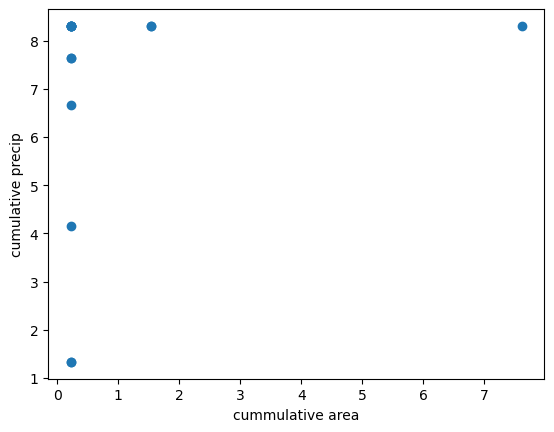

In [12]:
tmp = fires[fires.UfireID == '9982_2019']


plt.scatter(tmp.area_growth_at_t_km2.cumsum(), tmp.precipitation.cumsum())
plt.xlabel("cummulative area")
plt.ylabel("cumulative precip")

Text(0, 0.5, 'cumulative precip')

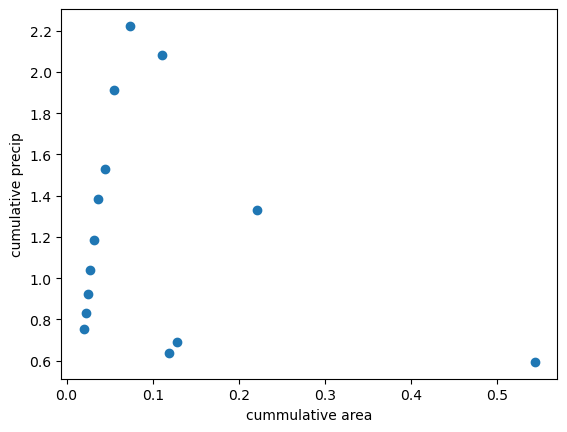

In [13]:
plt.scatter(tmp.area_growth_at_t_km2.cumsum()/tmp.start_off_12hrs, tmp.precipitation.cumsum()/tmp.start_off_12hrs)
plt.xlabel("cummulative area")
plt.ylabel("cumulative precip")

In [ ]:
plt.plot(tmp.t, tmp.area_growth_at_t_km2)
plt.plot(tmp.t, tmp.precipitation)

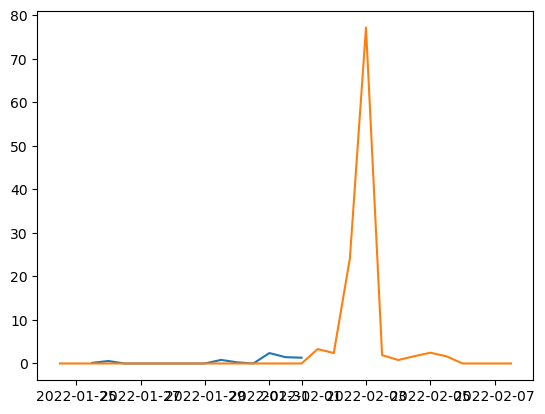

In [37]:
#tmp2 = fires[fires.UfireID == "10138_2013"] # NO precip
#tmp2 = fires[fires.UfireID == "10073_2022"] # NO precip
tmp2 = fires[fires.UfireID == "5047_2022"] # Has precip! Kind of a lot though

plt.plot(tmp2.t, tmp2.area_growth_at_t_km2)
plt.plot(tmp2.t, tmp2.precipitation)

In [15]:
### Jim's sampling scheme (rain before and after event)

thresh = 1

fires.loc[:, f"precip_over_{str(thresh)}"] = fires.precipitation >=1
# Odd: fine, no need to go back 24 hours pd.Timedelta(hours = 36) % pd.Timedelta(hours = 12)
# even: bad. need to go back 24 hours pd.Timedelta(hours = 48) % pd.Timedelta(hours = 12)
# zero: bad. no data to sample in that time period. Fail quietly? 
def sample_pre_post_precip(df, thresh):
    event_starts = df[f"precip_over_{thresh}"] & ~df[f"precip_over_{thresh}"].shift(1, fill_value=False)
    event_ends = df[f"precip_over_{thresh}"] & ~df[f"precip_over_{thresh}"].shift(-1, fill_value=False)
    start_indices = df[event_starts].t
    end_indices = df[event_ends].t

    
    samples = []

    for start, end in zip(start_indices, end_indices):
        lenght_rain = end - start

        if (((lenght_rain.total_seconds() / pd.Timedelta(hours = 12).total_seconds()) % 2) == 0):
            window_size = pd.Timedelta(hours=24) ## need to sample an AM increment and a PM increment
        else:
            window_size = pd.Timedelta(hours=12)

        
        # Define the windows (exclusive of the event itself)
        # Period before: [start - window] to [start - 1 timestep]
        
        period_before = df[((df.t >= (start - window_size)) & (df.t <= (start - pd.Timedelta(hours=12))))] ## Need to figure out how to do cummulative indexing for 1 or two 12 hour increments
        
        # Period after: [end + 1 timestep] to [end + window]
        period_after = df[(df.t <= (end - window_size))  & (df.t >= (end + pd.Timedelta(hours=12)))] ## not working
        
        samples.append({
            'event_start': start,
            'event_end': end,
            'before_sample': period_before,
            'after_sample': period_after
        })

    




In [16]:
# # def try_jims_sampleing_method(df, thresh):
# #     df = df[df.fr_active_status.isin(["post_fire", "during_fire"])] ## exclude precip before see fire
# #     if(len(df[df.precipitation >= thresh]) == 0):
# #         #t_precip_min = df[df.fr_active_status == "post_fire"].t.max()
# #         return([])
# #     t_precip_min = df[df.precipitation >= thresh ].t.min() ## First time over threshold
# #     t_vals = df[df.precipitation >= thresh ].t.unique()
# #     if((len(t_vals) ==1) & (t_vals[0] == t_precip_min)):
# #         t_max = df.t.max()


# def area_ratio_pre_post(df, thresh):
#     df = df[df.fr_active_status == 'during_fire']
#     if(len(df[df.precipitation >= thresh]) == 0): ## No rain over threshold
#         #t_precip_min = df[df.fr_active_status == "post_fire"].t.max()
#         return([])
#         t_vals = df[df.precipitation >= thresh ].t.unique()
#         n_steps_rain = 1
#         n_steps_growth_increment = 1

#         # ex = pd.DataFrame({"t": rain_days.t, "12_hour_fr_st": (rain_days.t.diff() > pd.Timedelta(hours = 12)), "12_hour_fr_end": (rain_days.t.diff(-1).abs() > pd.Timedelta(hours = 12))})
#         #sample_mask = df[df.precipitation >= thresh].t.diff() > pd.Timedelta(hours = 12) ## identifyies fire growth timesteps where can do the sampleing 
#         rain_days = pd.concat([df[df.precipitation >= thresh], df[df.t == df.t.min()], df[df.t == df.t.max()]])
#         rain_days = rain_days.sort_values(by = "t")

#         over_12_hours_from_start_mask = (rain_days.t.diff() > pd.Timedelta(hours = 12))
#         over_12_hours_from_end_mask = (rain_days.t.diff(-1).abs() > pd.Timedelta(hours = 12))
        
#         # for t in t_vals:
#         #     prev_t = t - pd.Timedelta(hours = 12)
#         #     post_t = t + pd.Timedelta(hours = 12)
#         #     if(len(df[df.t.isin(prev_t)]) == 0): ## the rain started right when the fire did. 
#         #         return([])
#         #     if(len(df[df.t.isin(post_t)]) == 0): ## The rain is the final part of the timeseries
#         #         return([])

#         #     if(len(df[(df.precipitation >= thresh) & df.t.isin([post_t])].t) < 0): ## The rain went for multiple days.
                
                
            
    
    
    

# ### Is this numerically right? COuld check by doing this to my no-precip fires and see if random incremens vs random increment works to check